# ROC Curve

Conda environment for this notebook: `conda env create`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
plt.rcParams['axes.prop_cycle'] = cycler('color', [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a"])

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

Just a simple diagram for explaining the ROC-curve with a perfect curve, an uninformative (basically random), and examples from the saved data in "testmodel"

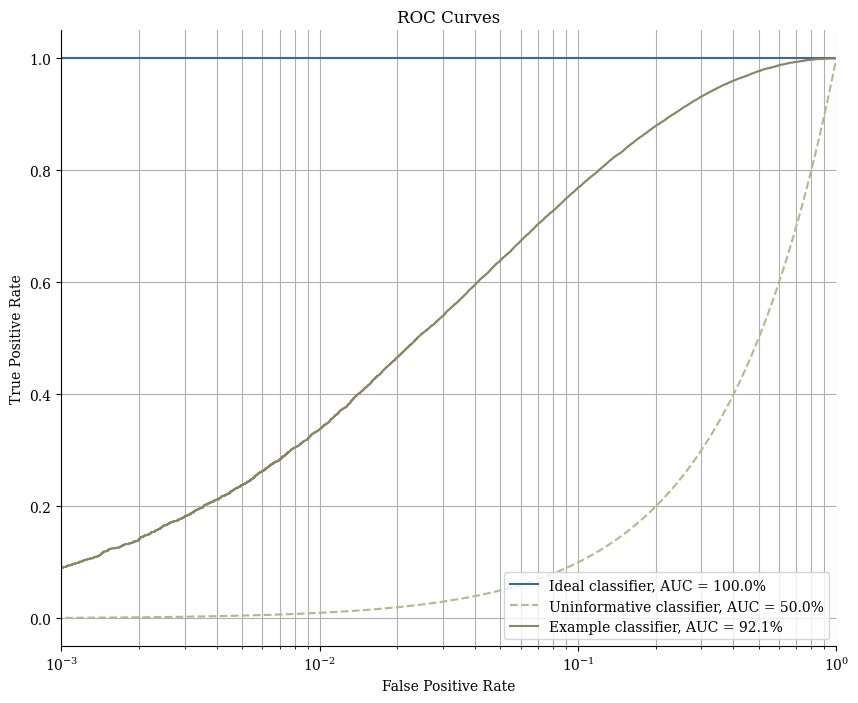

In [8]:
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../testmodel/y_keras.npy")

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-")
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--")
plotting.makeRoc(y_true, y_example, ["Example classifier"], linestyle="-")
plt.title("ROC Curves")
plt.show()

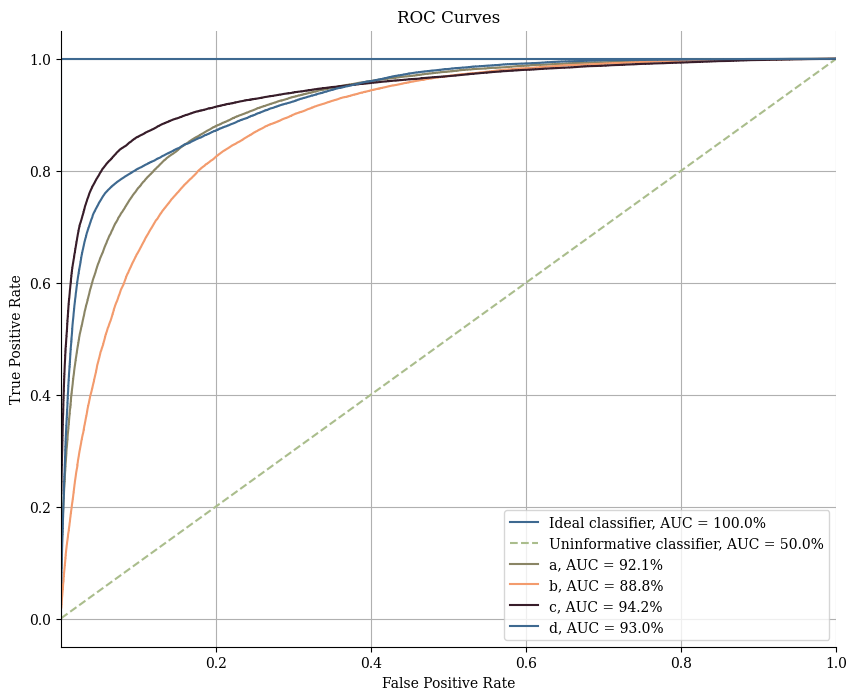

In [9]:
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../testmodel/y_keras.npy")
example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-", style_semilogx=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", style_semilogx=False)
plotting.makeRoc(y_true, y_example, ["a","b","c","d"], linestyle="-", style_semilogx=False)
plt.title("ROC Curves")
plt.show()

Put side by side for insight into how to analyze

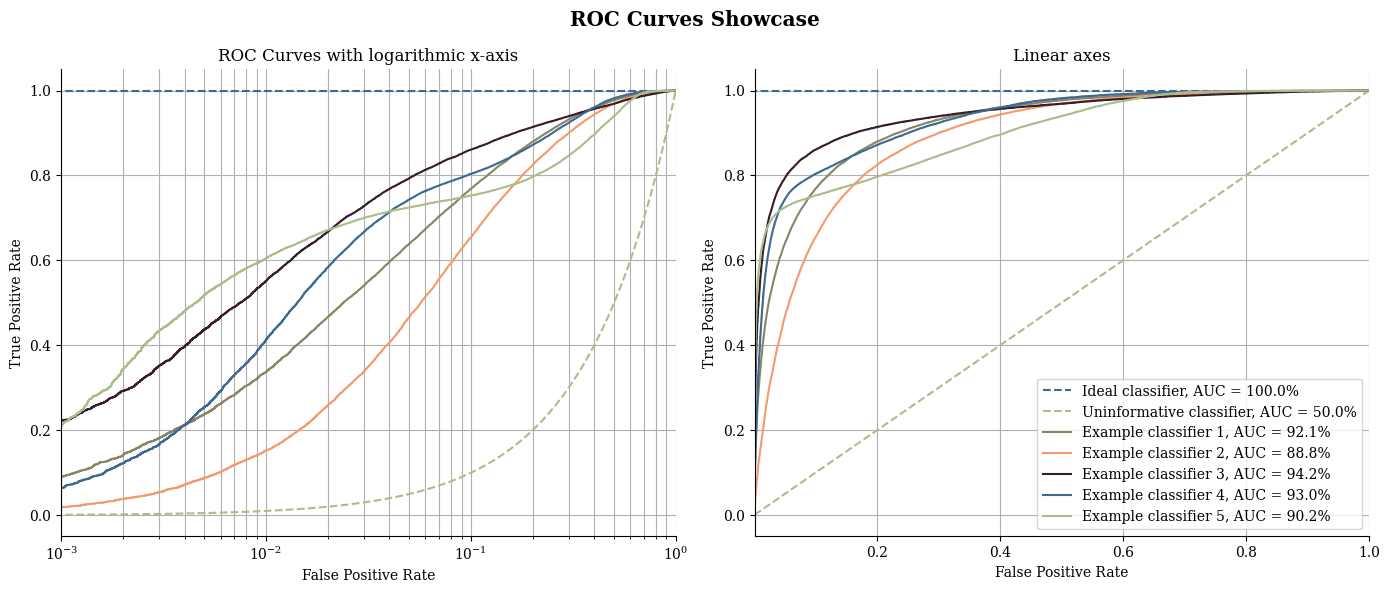

In [10]:
plotname = "ROC Curves Showcase"

y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

y_example = np.load("../testmodel/y_keras.npy")
#example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)
example_classes = ["Example classifier 1", "Example classifier 2", "Example classifier 3", "Example classifier 4", 
                   "Example classifier 5"] # Does not use the true names as its only an abstract showcase

y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axs[0])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", legend=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", legend=False)
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", style_semilogx=False, legend=False)
axs[0].set_title("ROC Curves with logarithmic x-axis")

plt.sca(axs[1])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", style_semilogx=False, style_legends='default')
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", style_semilogx=False, style_legends='default')
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", style_semilogx=False, style_legends='default')
axs[1].set_title("Linear axes")

plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()

fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")